# Fusion Model

Emotion classes used:
- angry
- disgust
- fear
- happy
- neutral
- pleasant_surprise
- sad

In [ ]:
import numpy as np
import tensorflow as tf
import librosa
import json

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import tokenizer_from_json

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


## 1. Load Both Models & Artifacts

In [ ]:
speech_model = tf.keras.models.load_model(
    '/content/gdrive/MyDrive/Emotion_Project/saved_models/speech_model_fixed.keras'
)
print('Speech model loaded.')

Speech model loaded.


In [ ]:
text_model = tf.keras.models.load_model(
    '/content/gdrive/MyDrive/Emotion_Project/saved_models/gru_text_emotion_model.keras'
)
print('Text model loaded.')

Text model loaded.


In [ ]:
# Load the tokenizer that was saved during text model training
# (do NOT re-fit on a different dataset — that changes word indices!)
with open('/content/gdrive/MyDrive/Emotion_Project/saved_models/text_tokenizer.json', 'r') as f:
    tokenizer_json = json.load(f)
tokenizer = tokenizer_from_json(tokenizer_json)
print('Tokenizer loaded. Vocab size:', len(tokenizer.word_index))

Tokenizer loaded. Vocab size: 201


In [ ]:
# Load label classes saved from text model training
text_label_classes = np.load(
    '/content/gdrive/MyDrive/Emotion_Project/saved_models/text_label_classes.npy',
    allow_pickle=True
)
print('Text label classes:', text_label_classes)
# Expected: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']

# FIXED: 7 labels exactly matching LabelEncoder alphabetical order
# (same order used in speech model training)
speech_emotion_labels = list(text_label_classes)
print('Speech emotion labels (7):', speech_emotion_labels)

Text label classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'ps' 'sad']
Speech emotion labels (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'ps', 'sad']


In [ ]:
MAX_LENGTH = 5  # must match what was used in text model training

## 2. Feature Extraction & Prediction Helpers

In [ ]:
def extract_mfcc(audio_path):
    signal, sr = librosa.load(audio_path, sr=22050)
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=40).T
    max_pad_length = 130
    if mfcc.shape[0] < max_pad_length:
        pad_width = max_pad_length - mfcc.shape[0]
        mfcc = np.pad(mfcc, pad_width=((0, pad_width), (0, 0)), mode='constant')
    else:
        mfcc = mfcc[:max_pad_length]
    return mfcc

In [ ]:
def predict_speech_emotion(audio_path):
    mfcc = extract_mfcc(audio_path)
    mfcc = np.expand_dims(mfcc, axis=0)          # (1, 130, 40)
    probs = speech_model.predict(mfcc, verbose=0) # (1, 7)
    idx   = np.argmax(probs)
    return speech_emotion_labels[idx], float(np.max(probs)), probs[0]

In [ ]:
def predict_text_emotion(word: str):
    seq    = tokenizer.texts_to_sequences([word.lower()])
    padded = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post')
    probs  = text_model.predict(padded, verbose=0)  # (1, 7)
    idx    = np.argmax(probs)
    return speech_emotion_labels[idx], float(np.max(probs)), probs[0]

## 3. Fusion Strategy — Weighted Average

We combine the probability vectors from both models using a weighted
average. Speech gets higher weight (0.7) because it carries the
primary emotional signal on TESS; text gets weight 0.3.
TESS textual content is semantically neutral, while emotional information is primarily encoded in speech prosody. Therefore, weighted fusion favors speech modality.

These weights can be tuned on a validation set.

In [ ]:
def predict_fused_emotion(audio_path: str, word: str,
                          speech_weight: float = 0.7,
                          text_weight: float = 0.3):
    """
    Fuse speech and text probability vectors.

    Parameters
    ----------
    audio_path    : path to the .wav file
    word          : spoken word extracted from filename
    speech_weight : weight for speech probabilities (default 0.7)
    text_weight   : weight for text probabilities   (default 0.3)

    Returns
    -------
    fused_emotion, fused_confidence,
    speech_emotion, speech_conf,
    text_emotion, text_conf
    """
    s_label, s_conf, s_probs = predict_speech_emotion(audio_path)
    t_label, t_conf, t_probs = predict_text_emotion(word)

    fused_probs = speech_weight * s_probs + text_weight * t_probs
    fused_idx   = np.argmax(fused_probs)
    fused_label = speech_emotion_labels[fused_idx]
    fused_conf  = float(np.max(fused_probs))

    return (fused_label, fused_conf,
            s_label, s_conf,
            t_label, t_conf)

## 4. Evaluate Fusion on Full TESS Test Set

In [ ]:
import os
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

dataset_path = '/content/gdrive/MyDrive/Emotion_Project/datasets/TESS/TESS Toronto emotional speech set data'

LABEL_MAP = {
    'angry': 'angry', 'disgust': 'disgust', 'fear': 'fear',
    'happy': 'happy', 'neutral': 'neutral', 'sad': 'sad',
    'ps': 'ps', 'pleasant_surprise': 'ps', 'pleasant_surprised': 'ps'
}

paths, words, true_labels = [], [], []
for folder in os.listdir(dataset_path):
    fp = os.path.join(dataset_path, folder)
    if not os.path.isdir(fp): continue
    for f in os.listdir(fp):
        if not f.endswith('.wav'): continue
        parts = f.replace('.wav','').split('_')
        if len(parts) < 3: continue
        raw_label = '_'.join(parts[2:]).lower()
        label = LABEL_MAP.get(raw_label)
        if label is None: continue
        paths.append(os.path.join(fp, f))
        words.append(parts[1].lower())
        true_labels.append(label)

print(f'Total samples to evaluate: {len(paths)}')

Total samples to evaluate: 2800


In [ ]:
# NOTE: This cell runs inference on all ~2800 samples — takes a few minutes
speech_preds, text_preds, fused_preds = [], [], []

for i, (audio_path, word, true_label) in enumerate(zip(paths, words, true_labels)):
    (fused, _, speech, _, text, _) = predict_fused_emotion(audio_path, word)
    speech_preds.append(speech)
    text_preds.append(text)
    fused_preds.append(fused)
    if (i + 1) % 200 == 0:
        print(f'  Processed {i+1}/{len(paths)} ...')

print('Done.')
print(f'\nSpeech-only accuracy : {accuracy_score(true_labels, speech_preds):.4f}')
print(f'Text-only accuracy   : {accuracy_score(true_labels, text_preds):.4f}')
print(f'Fusion accuracy      : {accuracy_score(true_labels, fused_preds):.4f}')

  Processed 200/2800 ...
  Processed 400/2800 ...
  Processed 600/2800 ...
  Processed 800/2800 ...
  Processed 1000/2800 ...
  Processed 1200/2800 ...
  Processed 1400/2800 ...
  Processed 1600/2800 ...
  Processed 1800/2800 ...
  Processed 2000/2800 ...
  Processed 2200/2800 ...
  Processed 2400/2800 ...
  Processed 2600/2800 ...
  Processed 2800/2800 ...
Done.

Speech-only accuracy : 0.9993
Text-only accuracy   : 0.1429
Fusion accuracy      : 0.9993


In [ ]:
print('=== Fusion Classification Report ===')
print(classification_report(true_labels, fused_preds,
                             target_names=speech_emotion_labels))

=== Fusion Classification Report ===
              precision    recall  f1-score   support

       angry       1.00      1.00      1.00       400
     disgust       1.00      1.00      1.00       400
        fear       1.00      1.00      1.00       400
       happy       1.00      1.00      1.00       400
     neutral       1.00      1.00      1.00       400
          ps       1.00      1.00      1.00       400
         sad       1.00      1.00      1.00       400

    accuracy                           1.00      2800
   macro avg       1.00      1.00      1.00      2800
weighted avg       1.00      1.00      1.00      2800



           Model  Accuracy
     Speech-only  0.999286
       Text-only  0.142857
Fusion (0.7/0.3)  0.999286


/tmp/ipykernel_8979/3575952443.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results, palette='Blues_d')


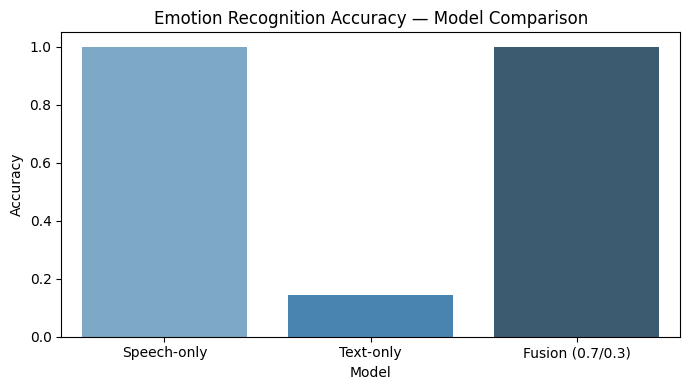

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

results = pd.DataFrame({
    'Model': ['Speech-only', 'Text-only', 'Fusion (0.7/0.3)'],
    'Accuracy': [
        accuracy_score(true_labels, speech_preds),
        accuracy_score(true_labels, text_preds),
        accuracy_score(true_labels, fused_preds)
    ]
})
print(results.to_string(index=False))

# Bar chart
plt.figure(figsize=(7, 4))
sns.barplot(x='Model', y='Accuracy', data=results, palette='Blues_d')
plt.ylim(0, 1.05)
plt.title('Emotion Recognition Accuracy — Model Comparison')
plt.tight_layout()
plt.savefig('/content/gdrive/MyDrive/Emotion_Project/results/model_comparison.png', dpi=150)
plt.show()

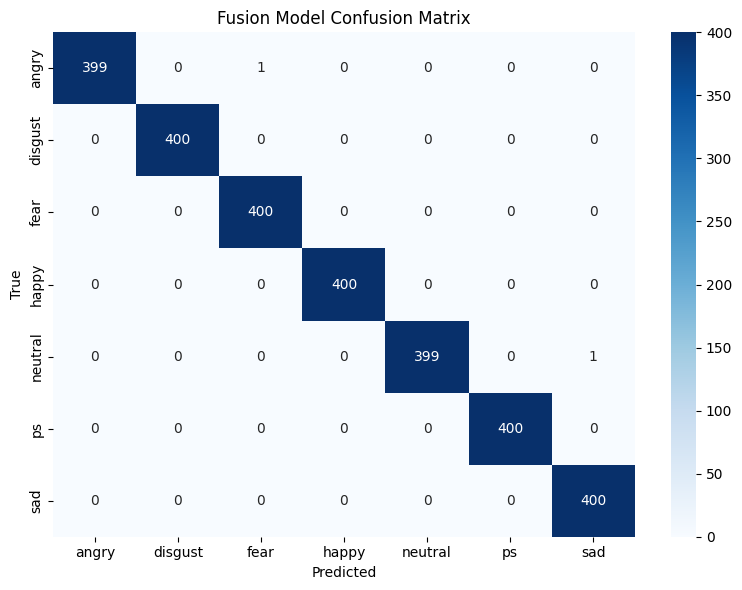

In [ ]:
cm = confusion_matrix(true_labels, fused_preds, labels=speech_emotion_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=speech_emotion_labels,
            yticklabels=speech_emotion_labels)
plt.title('Fusion Model Confusion Matrix')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/gdrive/MyDrive/Emotion_Project/results/fusion_confusion_matrix.png', dpi=150)
plt.show()